# Sign Language Digits 0-9
Training the same small 64x64 grayscale CNN for digit gesture recognition.


In [2]:
# import modules -----------------------------------------------------------------------------------
import math
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import callbacks
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import InputLayer, Flatten, Dense, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings('ignore')

# define paths -------------------------------------------------------------------------------------
project_root = Path('.') if Path('dataset_digits_gray64').exists() else Path('..')
dataset_root = project_root / 'dataset_digits_gray64'
models_dir = project_root / 'models'
train_folder = dataset_root / 'train'
test_folder = dataset_root / 'test'
validation_folder = dataset_root / 'validation'

image_shape = (64, 64, 1)
num_classes = 10
class_names = [str(i) for i in range(num_classes)]
model_name = 'digits_0_9'

# Helper methods -----------------------------------------------------------------------------------
def load_image(img_path: str | Path) -> np.ndarray:
    """Load an image and return grayscale 64x64 (H,W,1)."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, image_shape[:2], interpolation=cv2.INTER_AREA)
    img = img[..., np.newaxis]
    return img

def display_image(image_array: np.ndarray) -> None:
    plt.imshow(image_array.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

def save_digits_model(model: Sequential, name: str = model_name) -> None:
    """Save a model to models/<name>.h5."""
    models_dir.mkdir(parents=True, exist_ok=True)
    filename = models_dir / f'{name}.h5'
    model.save(filename)
    print(f'Saved model: {filename}')

def load_digits_model(model_path: str | Path | None = None):
    """Load a model from a file path. If no path is provided, load models/<model_name>.h5."""
    if model_path is None:
        model_path = models_dir / f'{model_name}.h5'
    model_path = Path(model_path)

    if not model_path.is_file():
        model_path = models_dir / sorted([m for m in os.listdir(models_dir) if m.lower().endswith('.h5')])[-1]

    loaded_model = load_model(model_path)
    print(f'Loaded model: {model_path} with input shape: {loaded_model.input_shape}')
    return loaded_model

def get_random_picture(split: str | None = None) -> str:
    """Return a random picture path from the train, test, or validation set."""
    if split == 'train':
        folder = train_folder
    elif split == 'test':
        folder = test_folder
    elif split == 'validation':
        folder = validation_folder
    else:
        folder = random.choice([train_folder, test_folder, validation_folder])

    subfolder = random.choice([p for p in os.listdir(folder) if (folder / p).is_dir()])
    subfolder_path = folder / subfolder
    test_image = random.choice(os.listdir(subfolder_path))
    return os.path.normpath(subfolder_path / test_image)


## Check dataset content

Image: ../dataset_digits_gray64/validation/4/IMG_5541.png


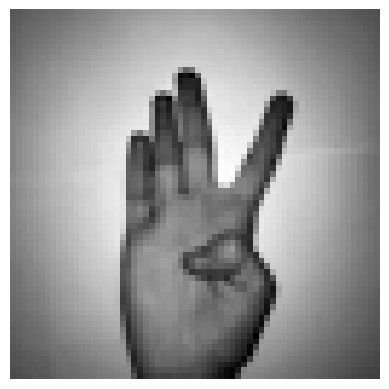

In [3]:
# open test picture
image_path = get_random_picture()
print('Image:', image_path)
img = load_image(image_path)
display_image(img)

## Preparing data for the model

Found 1444 images belonging to 10 classes.
Found 308 images belonging to 10 classes.
Found 310 images belonging to 10 classes.
x: (32, 64, 64, 1) y: (32, 10)


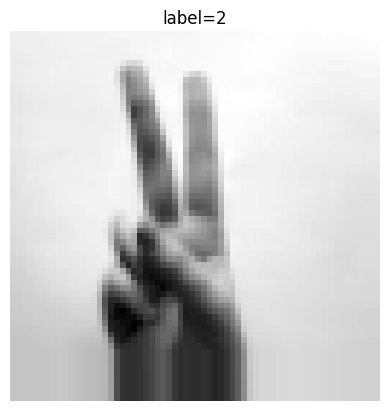

In [4]:
batch_size = 32

train_image_gen_config = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)

eval_image_gen_config = ImageDataGenerator(rescale=1.0 / 255.0)

train_image_gen = train_image_gen_config.flow_from_directory(
    train_folder,
    target_size=image_shape[:2],
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_image_gen = eval_image_gen_config.flow_from_directory(
    test_folder,
    target_size=image_shape[:2],
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

validation_generator = eval_image_gen_config.flow_from_directory(
    validation_folder,
    target_size=image_shape[:2],
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

expected_class_indices = {str(i): i for i in range(num_classes)}
if train_image_gen.class_indices != expected_class_indices:
    raise ValueError(f'Unexpected class mapping: {train_image_gen.class_indices}')

x, y = next(train_image_gen)
print('x:', x.shape, 'y:', y.shape)

plt.imshow(x[0].squeeze(), cmap='gray')
plt.title(f'label={np.argmax(y[0])}')
plt.axis('off')
plt.show()


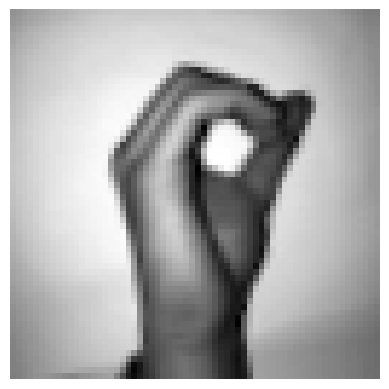

In [4]:
# test generator on random image
random_img = train_image_gen_config.random_transform(img)
display_image(random_img)


## Create Model

In [5]:
# create sequential model
# 3x3 filter1=4, filter2=8, filter3=8
model = Sequential()

# input: 64x64x1
model.add(InputLayer(input_shape=image_shape))

# Conv1: 3x3, Cin=1, Cout=4   => 62x62x4
model.add(Conv2D(filters=4, kernel_size=(3, 3), strides=(1, 1),
                 padding='valid', activation='relu'))
# Pool1: 2x2 => 31x31x4
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv2: 3x3, Cin=4, Cout=8   => 29x29x8
model.add(Conv2D(filters=8, kernel_size=(3, 3), strides=(1, 1),
                 padding='valid', activation='relu'))
# Pool2: 2x2 => 14x14x8
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv3: 3x3, Cin=8, Cout=8   => 12x12x8
model.add(Conv2D(filters=8, kernel_size=(3, 3), strides=(1, 1),
                 padding='valid', activation='relu'))
# Pool3: 2x2 => 6x6x8
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten => 288
model.add(Flatten())

# FC: 288 --> 10
model.add(Dense(units=num_classes, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,810 (14.88 KB)

 Trainable params: 3,810 (14.88 KB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [6]:
# indices
class_indices = train_image_gen.class_indices
class_labels = {v:k for k, v in class_indices.items()}
print(class_indices)
print(class_labels)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [7]:
# Initializing early stopping callback to monitor validation accuracy and prevent overfitting
earlystopping = callbacks.EarlyStopping(monitor='val_accuracy',
                                        mode='max',
                                        patience=30,
                                        restore_best_weights=True)


In [8]:
# Train the model
results = model.fit(
    train_image_gen,
    epochs=200,
    steps_per_epoch=math.ceil(train_image_gen.samples / train_image_gen.batch_size),
    validation_data=validation_generator,
    validation_steps=math.ceil(validation_generator.samples / validation_generator.batch_size),
    verbose=2,
    callbacks=[earlystopping]
)


Epoch 1/200
46/46 - 1s - 21ms/step - accuracy: 0.1053 - loss: 2.3095 - val_accuracy: 0.1323 - val_loss: 2.2951
Epoch 2/200
46/46 - 0s - 7ms/step - accuracy: 0.1745 - loss: 2.2877 - val_accuracy: 0.3032 - val_loss: 2.2575
Epoch 3/200
46/46 - 0s - 7ms/step - accuracy: 0.2368 - loss: 2.2419 - val_accuracy: 0.4129 - val_loss: 2.0998
Epoch 4/200
46/46 - 0s - 7ms/step - accuracy: 0.3206 - loss: 2.0343 - val_accuracy: 0.5452 - val_loss: 1.6410
Epoch 5/200
46/46 - 0s - 7ms/step - accuracy: 0.3989 - loss: 1.7356 - val_accuracy: 0.5903 - val_loss: 1.2969
Epoch 6/200
46/46 - 0s - 8ms/step - accuracy: 0.4633 - loss: 1.5525 - val_accuracy: 0.6774 - val_loss: 1.0367
Epoch 7/200
46/46 - 0s - 7ms/step - accuracy: 0.5007 - loss: 1.4521 - val_accuracy: 0.6871 - val_loss: 0.9712
Epoch 8/200
46/46 - 0s - 7ms/step - accuracy: 0.5339 - loss: 1.3395 - val_accuracy: 0.7419 - val_loss: 0.8576
Epoch 9/200
46/46 - 0s - 7ms/step - accuracy: 0.5319 - loss: 1.3364 - val_accuracy: 0.7355 - val_loss: 0.8308
Epoch 10/

## Visualize Accuracy

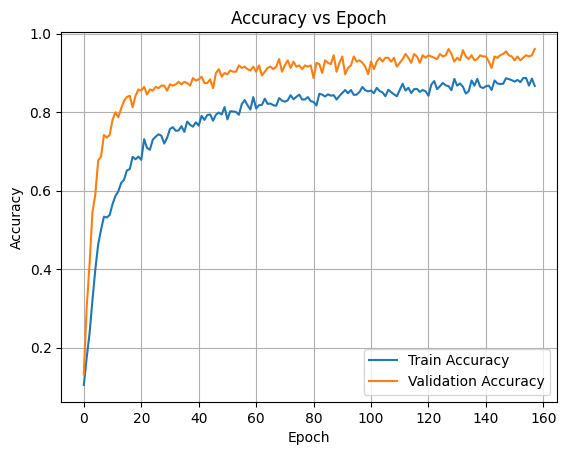

In [9]:
plt.plot(results.history['accuracy'], label='Train Accuracy')
plt.plot(results.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


## Save model

In [10]:
model_name = "v1"
save_digits_model(model, model_name)


Saved model: ../models/v1.h5


## Export INT8 TFLite (PTQ)
Use post-training quantization (PTQ) to export a full-int8 `.tflite` model directly in this notebook.


In [11]:
from pathlib import Path
import subprocess
import sys
import textwrap

# Self-contained config for this export cell. This keeps the cell runnable even
# if the notebook kernel was restarted or earlier path cells were skipped.
project_root = Path('.') if Path('dataset_digits_gray64').exists() else Path('..')
dataset_root = project_root / 'dataset_digits_gray64'
models_dir = project_root / 'models'
train_folder = dataset_root / 'train'
num_classes = 10
model_name = 'v1'

# 1) save current floating model
save_digits_model(model, model_name)

# 2) use the freshly saved floating model
model_h5 = models_dir / f'{model_name}.h5'
if not model_h5.exists():
    raise FileNotFoundError(f'No saved floating model found: {model_h5}')

out_path = models_dir / f'{model_name}.int8.tflite'
print(f'[INFO] Source model: {model_h5}')

# PTQ representative dataset config
per_class_samples = 120
print(f'[INFO] representative per-class samples: {per_class_samples}')

# 3) run PTQ conversion in subprocess to isolate TensorFlow converter state.
# TF 2.16 can abort with TFLiteConverter.from_keras_model() for this Keras model,
# so this path exports a temporary SavedModel first and converts from that.
script = textwrap.dedent("""
import shutil
import sys
import tempfile
from pathlib import Path

import numpy as np
import tensorflow as tf

model_path = Path(sys.argv[1])
rep_dir = Path(sys.argv[2])
out_path = Path(sys.argv[3])
per_class_samples = int(sys.argv[4])
num_classes = int(sys.argv[5])

float_model = tf.keras.models.load_model(str(model_path), compile=False)
float_model(np.zeros((1, 64, 64, 1), dtype=np.float32))

def representative_dataset_gen():
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    class_dirs = sorted([d for d in rep_dir.iterdir() if d.is_dir()], key=lambda p: int(p.name))
    if not class_dirs:
        raise FileNotFoundError(f'No class subdirs found in {rep_dir}')

    picked = []
    class_counts = {}
    for d in class_dirs:
        files = [p for p in sorted(d.rglob('*')) if p.suffix.lower() in exts]
        take = min(per_class_samples, len(files))
        picked.extend(files[:take])
        class_counts[d.name] = take

    total = len(picked)
    if total == 0:
        raise FileNotFoundError(f'No representative images found in {rep_dir}')

    print('[INFO] representative class counts:', class_counts)
    print('[INFO] representative total:', total)

    for p in picked:
        img = tf.keras.utils.load_img(p, color_mode='grayscale', target_size=(64, 64))
        arr = tf.keras.utils.img_to_array(img).astype(np.float32) / 255.0
        arr = np.expand_dims(arr, axis=0)
        yield [arr]

with tempfile.TemporaryDirectory(prefix='digits_saved_model_') as tmp:
    saved_model_dir = Path(tmp) / 'saved_model'
    float_model.export(saved_model_dir)

    converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

out_path.write_bytes(tflite_model)

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
in_detail = interpreter.get_input_details()[0]
out_detail = interpreter.get_output_details()[0]

print(f'[OK] Saved int8 model: {out_path}')
print('[INFO] Input dtype/quant:', in_detail['dtype'].__name__, in_detail['quantization'])
print('[INFO] Output shape/dtype/quant:', out_detail['shape'], out_detail['dtype'].__name__, out_detail['quantization'])
""")

preferred_py = project_root / '.venv/bin/python'
runner = str(preferred_py) if preferred_py.exists() else sys.executable
print(f'[INFO] Python runner: {runner}')
if not preferred_py.exists():
    print('[WARN] .venv not found, fallback to current kernel python.')

cmd = [runner, '-c', script, str(model_h5), str(train_folder), str(out_path), str(per_class_samples), str(num_classes)]
print('[INFO] Running conversion in subprocess...')
res = subprocess.run(cmd, capture_output=True, text=True)

print('----- STDOUT -----')
print(res.stdout if res.stdout else '<empty>')
print('----- STDERR -----')
print(res.stderr if res.stderr else '<empty>')

if res.returncode != 0:
    raise RuntimeError(f'PTQ conversion failed (return code={res.returncode}). See logs above.')
print('[OK] PTQ conversion finished.')


Saved model: ../models/v1.h5
[INFO] Source model: ../models/v1.h5
[INFO] representative per-class samples: 120
[INFO] Python runner: ../.venv/bin/python
[INFO] Running conversion in subprocess...
----- STDOUT -----
Saved artifact at '/var/folders/xw/f5202ph93xd7ycbz7dvw7mrh0000gn/T/digits_saved_model_16yhj5s3/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  5342723088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5330346480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5343809552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5343810432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5343811136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5343810256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5343811664: TensorSpec(shape=(), dtype=

In [12]:
import numpy as np
import tensorflow as tf

itp = tf.lite.Interpreter(model_path=str(models_dir / f'{model_name}.int8.tflite'))
itp.allocate_tensors()
all_d = itp.get_tensor_details()

print('[INPUT]')
for d in itp.get_input_details():
    q = d['quantization_parameters']
    print(d['index'], d['name'], np.dtype(d['dtype']), 'zp=', q['zero_points'], 'scale=', q['scales'])

print()
print('[OUTPUT]')
for d in itp.get_output_details():
    q = d['quantization_parameters']
    print(d['index'], d['name'], np.dtype(d['dtype']), 'zp=', q['zero_points'], 'scale=', q['scales'])

print()
print('[ALL QUANT TENSORS]')
for d in all_d:
    q = d['quantization_parameters']
    if q['scales'].size > 0:
        print(d['index'], d['name'], np.dtype(d['dtype']),
              'zp_len=', q['zero_points'].size,
              'zp_sample=', q['zero_points'][:8],
              'qdim=', q['quantized_dimension'])


[INPUT]
0 serving_default_input_layer:0 int8 zp= [-128] scale= [0.00390619]

[OUTPUT]
23 StatefulPartitionedCall_1:0 int8 zp= [-128] scale= [0.00390625]

[ALL QUANT TENSORS]
0 serving_default_input_layer:0 int8 zp_len= 1 zp_sample= [-128] qdim= 0
4 tfl.pseudo_qconst int32 zp_len= 1 zp_sample= [0] qdim= 0
5 tfl.pseudo_qconst1 int8 zp_len= 1 zp_sample= [0] qdim= 0
6 tfl.pseudo_qconst2 int32 zp_len= 8 zp_sample= [0 0 0 0 0 0 0 0] qdim= 0
7 tfl.pseudo_qconst3 int8 zp_len= 8 zp_sample= [0 0 0 0 0 0 0 0] qdim= 0
8 tfl.pseudo_qconst4 int32 zp_len= 8 zp_sample= [0 0 0 0 0 0 0 0] qdim= 0
9 tfl.pseudo_qconst5 int8 zp_len= 8 zp_sample= [0 0 0 0 0 0 0 0] qdim= 0
10 tfl.pseudo_qconst6 int32 zp_len= 4 zp_sample= [0 0 0 0] qdim= 0
11 tfl.pseudo_qconst7 int8 zp_len= 4 zp_sample= [0 0 0 0] qdim= 0
12 sequential_1/conv2d_1/Relu;sequential_1/conv2d_1/BiasAdd;sequential_1/conv2d_1/convolution;1 int8 zp_len= 1 zp_sample= [-128] qdim= 0
13 sequential_1/max_pooling2d_1/MaxPool2d int8 zp_len= 1 zp_sample= [-1

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [13]:
import numpy as np
import tensorflow as tf

interp = tf.lite.Interpreter(
    model_path=str(models_dir / f'{model_name}.int8.tflite'),
    experimental_preserve_all_tensors=True,
    experimental_delegates=[]
)
interp.allocate_tensors()

sample_path = Path(get_random_picture('test'))
inp = interp.get_input_details()[0]
in_scale, in_zero = inp['quantization']
img = tf.keras.utils.load_img(sample_path, color_mode='grayscale', target_size=image_shape[:2])
x = tf.keras.utils.img_to_array(img).astype(np.float32) / 255.0
x_q = np.clip(np.round(x[np.newaxis, ...] / in_scale + in_zero), -128, 127).astype(np.int8)
interp.set_tensor(inp['index'], x_q)
interp.invoke()

td = interp.get_tensor_details()
target = [d for d in td if 'conv2d_2/Relu' in d['name']][0]
y = interp.get_tensor(target['index'])

np.save('conv3_ref.npy', y)
print('image:', sample_path)
print('saved conv3_ref.npy', target['name'], y.shape, y.min(), y.max())


IndexError: list index out of range

## Confusion Matrix and Classification Report

In [14]:
validation_generator.reset()
validation_steps = math.ceil(validation_generator.samples / validation_generator.batch_size)

predictions = model.predict(validation_generator, steps=validation_steps, verbose=1)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = validation_generator.classes[:len(y_pred_classes)]
labels = [class_labels[i] for i in range(len(class_labels))]

print('Classification Report:')
print(classification_report(y_true, y_pred_classes, target_names=labels, digits=4))

print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred_classes))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        31
           1     1.0000    1.0000    1.0000        31
           2     0.9118    1.0000    0.9538        31
           3     1.0000    0.9677    0.9836        31
           4     0.9655    0.9032    0.9333        31
           5     1.0000    1.0000    1.0000        31
           6     0.9062    0.9355    0.9206        31
           7     0.8529    0.9355    0.8923        31
           8     1.0000    0.8710    0.9310        31
           9     1.0000    1.0000    1.0000        31

    accuracy                         0.9613       310
   macro avg     0.9636    0.9613    0.9615       310
weighted avg     0.9636    0.9613    0.9615       310

Confusion Matrix:
[[31  0  0  0  0  0  0  0  0  0]
 [ 0 31  0  0  0  0  0  0  0  0]
 [ 0  0 31  0  0  0  0  0  0  0]
 [ 0  0  0 30  0  0  0  1  0  0]
 [ 0  0  0  0 28  0  2  1  0 

## Classify Validation Pictures
Run all validation pictures through the model and classify them. Display the failed ones.

In [15]:
input_model_size = tuple(model.input_shape[1:3])
print('Model input size:', input_model_size)

success = 0
failure = 0
total = 0
failed_images = []

class_indices = validation_generator.class_indices
class_labels = {v: k for k, v in class_indices.items()}
print('class_indices:', class_indices)

test_images = None
idx = 0

for subfolder in class_names:
    current_folder = validation_folder / subfolder

    for img_name in os.listdir(current_folder):
        if test_images is not None and idx > test_images - 1:
            break
        idx += 1

        img_file = current_folder / img_name
        img_pil = image.load_img(img_file, target_size=input_model_size, color_mode='grayscale')
        img_array = image.img_to_array(img_pil)

        img_normalized = img_array / 255.0
        img_expanded = np.expand_dims(img_normalized, axis=0)

        prediction_prob = model.predict(img_expanded, verbose=0)
        predicted_class_index = int(np.argmax(prediction_prob[0], axis=-1))
        predicted_class_label = class_labels[predicted_class_index]

        if subfolder == predicted_class_label:
            success += 1
        else:
            failure += 1
            failed_images.append((img_normalized, predicted_class_label, img_file))

        total += 1
        to_print = f'Images Classified: {total} | Success: {success} | Failure: {failure} | Accuracy: {success/total*100:.2f}%'
        print(to_print, end=chr(13), flush=True)

print()


Model input size: (64, 64)
class_indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}
Images Classified: 310 | Success: 298 | Failure: 12 | Accuracy: 96.13%


## Compare the int8 model result with the floating32 model

In [16]:
from pathlib import Path
import numpy as np
import tensorflow as tf

# ====== config ======
val_root = validation_folder
h5_path = models_dir / f'{model_name}.h5'
tflite_path = models_dir / f'{model_name}.int8.tflite'
thumb_size = image_shape[:2]
exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ====== class setup ======
class_names_eval = sorted([d.name for d in val_root.iterdir() if d.is_dir()], key=int)
class_to_idx = {c: i for i, c in enumerate(class_names_eval)}

samples = []
for cname in class_names_eval:
    for p in sorted((val_root / cname).iterdir()):
        if p.suffix.lower() in exts:
            samples.append((p, class_to_idx[cname]))

print('[INFO] classes:', class_names_eval)
print('[INFO] total samples:', len(samples))
print('[INFO] h5:', h5_path)
print('[INFO] tflite:', tflite_path)

# ====== float model ======
float_model = tf.keras.models.load_model(str(h5_path), compile=False)

# ====== int8 tflite ======
interp = tf.lite.Interpreter(model_path=str(tflite_path))
interp.allocate_tensors()
in_d = interp.get_input_details()[0]
out_d = interp.get_output_details()[0]
in_scale, in_zero = in_d['quantization']
out_scale, out_zero = out_d['quantization']

print('[INFO] tflite input quant:', in_d['quantization'])
print('[INFO] tflite output quant:', out_d['quantization'])

# ====== eval both ======
y_true = []
y_pred_float = []
y_pred_int8 = []

for p, true_idx in samples:
    img = tf.keras.utils.load_img(p, color_mode='grayscale', target_size=thumb_size)
    x = tf.keras.utils.img_to_array(img).astype(np.float32) / 255.0
    x = x[np.newaxis, ...]

    y_f = float_model.predict(x, verbose=0)[0]
    pf = int(np.argmax(y_f))

    x_q = np.clip(np.round(x / in_scale + in_zero), -128, 127).astype(np.int8)
    interp.set_tensor(in_d['index'], x_q)
    interp.invoke()
    y_q = interp.get_tensor(out_d['index'])[0]
    y_i = (y_q.astype(np.float32) - out_zero) * out_scale
    pi = int(np.argmax(y_i))

    y_true.append(true_idx)
    y_pred_float.append(pf)
    y_pred_int8.append(pi)

y_true = np.array(y_true)
y_pred_float = np.array(y_pred_float)
y_pred_int8 = np.array(y_pred_int8)

acc_f = (y_true == y_pred_float).mean()
acc_i = (y_true == y_pred_int8).mean()

print()
print(f'[RESULT] float acc = {acc_f:.4f}')
print(f'[RESULT] int8  acc = {acc_i:.4f}')
print(f'[RESULT] delta(int8-float) = {acc_i - acc_f:+.4f}')

agree = (y_pred_float == y_pred_int8).mean()
print(f'[RESULT] float/int8 prediction agreement = {agree:.4f}')

print()
print('[PER-CLASS]')
for cname, idx in class_to_idx.items():
    m = (y_true == idx)
    af = (y_pred_float[m] == idx).mean() if m.any() else 0.0
    ai = (y_pred_int8[m] == idx).mean() if m.any() else 0.0
    print(f'{cname:<10} n={m.sum():<4} float={af:.4f} int8={ai:.4f} delta={ai-af:+.4f}')


[INFO] classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
[INFO] total samples: 310
[INFO] h5: ../models/v1.h5
[INFO] tflite: ../models/v1.int8.tflite
[INFO] tflite input quant: (0.0039061899296939373, -128)
[INFO] tflite output quant: (0.00390625, -128)

[RESULT] float acc = 0.9613
[RESULT] int8  acc = 0.9581
[RESULT] delta(int8-float) = -0.0032
[RESULT] float/int8 prediction agreement = 0.9968

[PER-CLASS]
0          n=31   float=1.0000 int8=1.0000 delta=+0.0000
1          n=31   float=1.0000 int8=1.0000 delta=+0.0000
2          n=31   float=1.0000 int8=1.0000 delta=+0.0000
3          n=31   float=0.9677 int8=0.9677 delta=+0.0000
4          n=31   float=0.9032 int8=0.9032 delta=+0.0000
5          n=31   float=1.0000 int8=1.0000 delta=+0.0000
6          n=31   float=0.9355 int8=0.9355 delta=+0.0000
7          n=31   float=0.9355 int8=0.9355 delta=+0.0000
8          n=31   float=0.8710 int8=0.8387 delta=-0.0323
9          n=31   float=1.0000 int8=1.0000 delta=+0.0000


In [ ]:
# INT8-only validation
from pathlib import Path
import numpy as np
import tensorflow as tf

val_root = validation_folder
tflite_path = models_dir / f'{model_name}.int8.tflite'
thumb_size = image_shape[:2]
exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class_names_eval = sorted([d.name for d in val_root.iterdir() if d.is_dir()], key=int)
class_to_idx = {c: i for i, c in enumerate(class_names_eval)}

samples = []
for cname in class_names_eval:
    for p in sorted((val_root / cname).iterdir()):
        if p.suffix.lower() in exts:
            samples.append((p, class_to_idx[cname]))

interp = tf.lite.Interpreter(model_path=str(tflite_path))
interp.allocate_tensors()
in_d = interp.get_input_details()[0]
out_d = interp.get_output_details()[0]
in_scale, in_zero = in_d['quantization']
out_scale, out_zero = out_d['quantization']

print('[INFO] classes:', class_names_eval)
print('[INFO] total samples:', len(samples))
print('[INFO] tflite:', tflite_path)
print('[INFO] tflite input quant:', in_d['quantization'])
print('[INFO] tflite output quant:', out_d['quantization'])

y_true = []
y_pred_int8 = []

for p, true_idx in samples:
    img = tf.keras.utils.load_img(p, color_mode='grayscale', target_size=thumb_size)
    x = tf.keras.utils.img_to_array(img).astype(np.float32) / 255.0
    x = x[np.newaxis, ...]

    x_q = np.clip(np.round(x / in_scale + in_zero), -128, 127).astype(np.int8)
    interp.set_tensor(in_d['index'], x_q)
    interp.invoke()
    y_q = interp.get_tensor(out_d['index'])[0]
    y_i = (y_q.astype(np.float32) - out_zero) * out_scale
    pi = int(np.argmax(y_i))

    y_true.append(true_idx)
    y_pred_int8.append(pi)

y_true = np.array(y_true)
y_pred_int8 = np.array(y_pred_int8)

acc_i = (y_true == y_pred_int8).mean()
print()
print(f'[RESULT] int8 acc = {acc_i:.4f}')

print()
print('[PER-CLASS int8]')
for cname, idx in class_to_idx.items():
    m = (y_true == idx)
    ai = (y_pred_int8[m] == idx).mean() if m.any() else 0.0
    print(f'{cname:<10} n={m.sum():<4} int8={ai:.4f}')

num_classes_eval = len(class_names_eval)
cm = np.zeros((num_classes_eval, num_classes_eval), dtype=np.int32)
for t, p in zip(y_true, y_pred_int8):
    cm[t, p] += 1

print()
print('[CONFUSION MATRIX] rows=true, cols=pred')
print('labels:', class_names_eval)
print(cm)
